# 🎯 SkillLens AI — Resume Intelligence System
### Research Paper Implementation: Skill Extraction · Job Role Prediction · Skill Gap Analysis

---

| Component | Technology |
|-----------|------------|
| Embeddings | Sentence-BERT (`all-mpnet-base-v2`) |
| Vector DB | FAISS (IndexFlatIP) |
| Classifiers | SVM · XGBoost · LightGBM · Voting Ensemble |
| Skill NER | spaCy `en_core_web_lg` + Custom Dictionary |
| PDF Parser | pdfplumber + pytesseract (OCR fallback) |
| Metrics | Accuracy · Precision · Recall · F1 · Top-K · MRR |

---

## 🔗 STEP 0 — Mount Google Drive

In [ ]:
# ── Mount Google Drive ────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Verify your files are accessible ─────────────────────────────────────────
import os
DRIVE_BASE = '/content/drive/MyDrive/resume_project'
print('✅ Files in your Drive folder:')
print(os.listdir(DRIVE_BASE))

Mounted at /content/drive
✅ Files in your Drive folder:
['job_dataset.csv', 'resume_data.csv', 'resume.zip', 'resume_dataset.csv', 'resumes_extracted', 'clean_resumes']


## 📦 STEP 1 — Install All Dependencies

In [ ]:
import subprocess, sys

packages = [
    'sentence-transformers', 'faiss-cpu', 'pdfplumber',
    'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn',
    'xgboost', 'lightgbm', 'spacy', 'nltk', 'tqdm', 'joblib',
    'imbalanced-learn', 'Pillow'
]
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

subprocess.check_call([sys.executable, '-m', 'spacy', 'download', 'en_core_web_lg'])
print('✅ All dependencies installed!')

✅ All dependencies installed!


## 📚 STEP 2 — Imports & Global Config

In [ ]:
# ── Standard ──────────────────────────────────────────────────────────────────
import os, re, ast, json, warnings, time
warnings.filterwarnings('ignore')

# ── Data ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── NLP ───────────────────────────────────────────────────────────────────────
import nltk, spacy
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
for pkg in ['stopwords','punkt','wordnet','punkt_tab']:
    nltk.download(pkg, quiet=True)
nlp = spacy.load('en_core_web_lg')

# ── Embeddings & FAISS ────────────────────────────────────────────────────────
from sentence_transformers import SentenceTransformer
import faiss

# ── ML ────────────────────────────────────────────────────────────────────────
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
import joblib

# ── PDF ───────────────────────────────────────────────────────────────────────
import pdfplumber

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm
from IPython.display import display, HTML

plt.rcParams['figure.dpi'] = 130
sns.set_theme(style='whitegrid', palette='husl')

# ── ✅ PATHS — GOOGLE DRIVE (resume_project folder) ───────────────────────────
DRIVE_BASE  = '/content/drive/MyDrive/resume_project'
RESUME_CSV  = f'{DRIVE_BASE}/resume_data.csv'
JOBROLE_CSV = f'{DRIVE_BASE}/job_dataset.csv'
MODEL_DIR   = f'{DRIVE_BASE}/skilllens_models'
os.makedirs(MODEL_DIR, exist_ok=True)

SBERT_MODEL = 'all-mpnet-base-v2'
print('✅ Imports done | SBERT model:', SBERT_MODEL)
print('✅ Resume CSV  :', RESUME_CSV)
print('✅ JobRole CSV :', JOBROLE_CSV)
print('✅ Model DIR   :', MODEL_DIR)

✅ Imports done | SBERT model: all-mpnet-base-v2
✅ Resume CSV  : /content/drive/MyDrive/resume_project/resume_data.csv
✅ JobRole CSV : /content/drive/MyDrive/resume_project/job_dataset.csv
✅ Model DIR   : /content/drive/MyDrive/resume_project/skilllens_models


## 🗂 STEP 3 — Load & Explore Datasets

RESUME DATASET
  Rows : 9,544
  Cols : 35
  Target classes (job_position_name): 28

JOB ROLES DATASET
  Rows : 1,068
  Cols : 7
  Unique job titles: 218


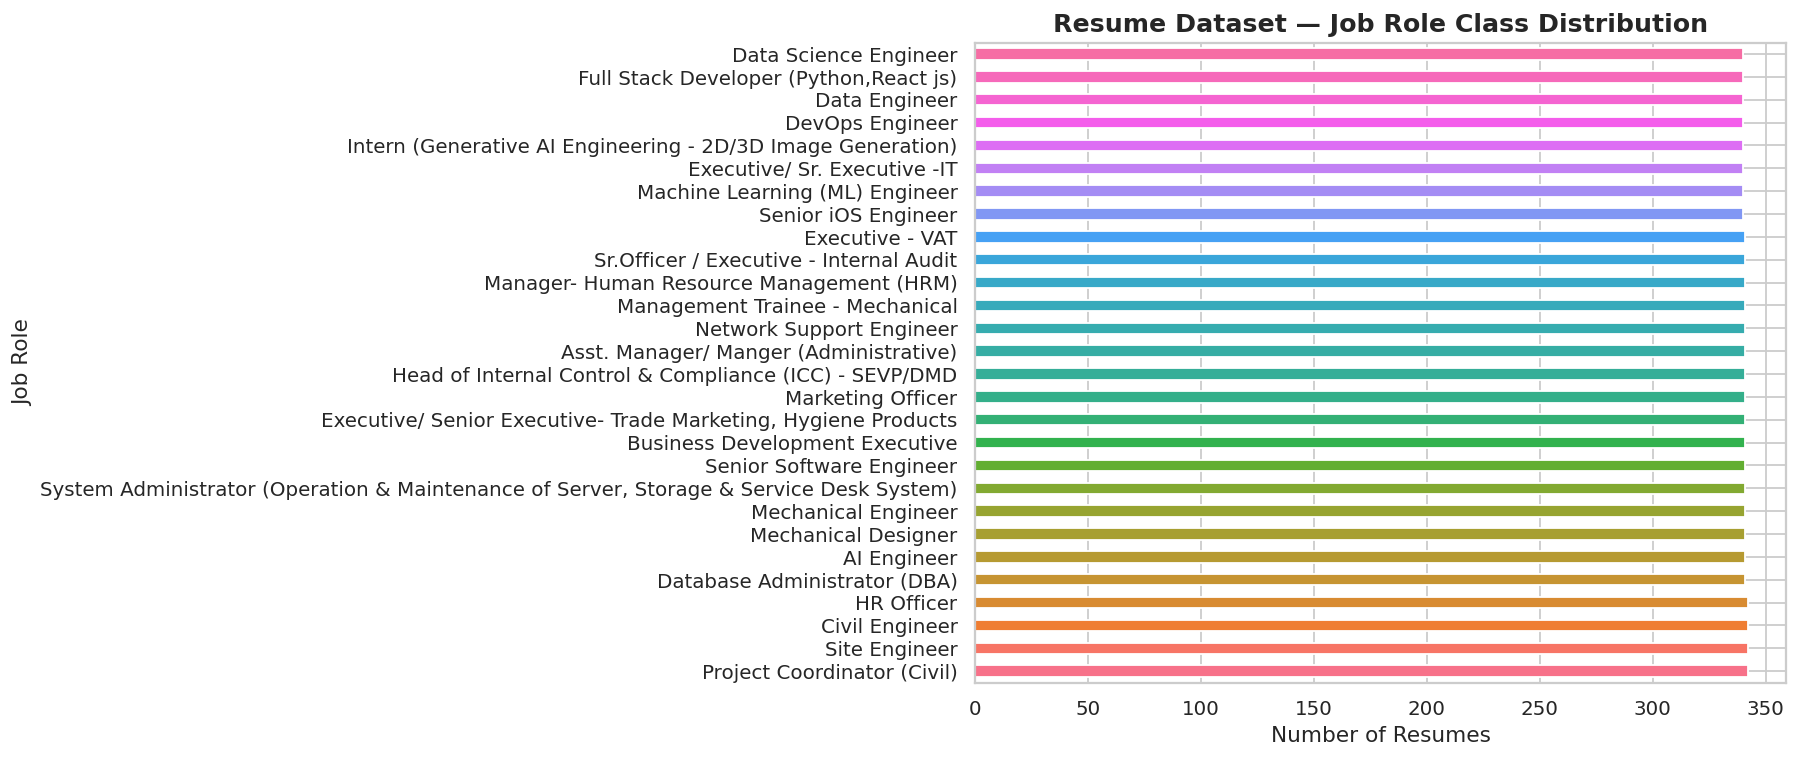


✅ Classes are well-balanced (~341 per class)


In [ ]:
# ── Load ──────────────────────────────────────────────────────────────────────
resume_df  = pd.read_csv(RESUME_CSV)
jobrole_df = pd.read_csv(JOBROLE_CSV)

# Fix BOM character in column name
resume_df.columns = [c.lstrip('\ufeff') for c in resume_df.columns]

print('='*60)
print('RESUME DATASET')
print(f'  Rows : {resume_df.shape[0]:,}')
print(f'  Cols : {resume_df.shape[1]}')
print(f'  Target classes (job_position_name): {resume_df["job_position_name"].nunique()}')
print()
print('JOB ROLES DATASET')
print(f'  Rows : {jobrole_df.shape[0]:,}')
print(f'  Cols : {jobrole_df.shape[1]}')
print(f'  Unique job titles: {jobrole_df["Title"].nunique()}')
print('='*60)

# ── Class distribution plot ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
counts = resume_df['job_position_name'].str.strip().value_counts()
counts.plot(kind='barh', ax=ax, color=sns.color_palette('husl', len(counts)))
ax.set_title('Resume Dataset — Job Role Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Resumes')
ax.set_ylabel('Job Role')
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/class_distribution.png', bbox_inches='tight')
plt.show()
print(f'\n✅ Classes are well-balanced (~{counts.mean():.0f} per class)')

## 🧹 STEP 4 — Skill Dictionary from Job Dataset

In [ ]:
def build_skill_dictionary(job_df: pd.DataFrame) -> set:
    """
    Extracts a comprehensive skill dictionary from the job dataset.
    Skills are semicolon-separated in the 'Skills' and 'Keywords' columns.
    """
    skill_set = set()
    for col in ['Skills', 'Keywords']:
        if col not in job_df.columns:
            continue
        for entry in job_df[col].dropna():
            for skill in str(entry).split(';'):
                s = skill.strip().lower()
                if s and len(s) > 1:
                    skill_set.add(s)
    return skill_set

SKILL_DICT = build_skill_dictionary(jobrole_df)

# Add common tech skills not in dataset
EXTRA_SKILLS = {
    'python','java','javascript','typescript','c++','c#','r','sql','nosql',
    'tensorflow','pytorch','keras','scikit-learn','pandas','numpy','matplotlib',
    'docker','kubernetes','aws','azure','gcp','hadoop','spark','kafka','airflow',
    'react','angular','vue','node.js','django','flask','fastapi','spring boot',
    'mysql','postgresql','mongodb','redis','elasticsearch','tableau','power bi',
    'machine learning','deep learning','nlp','computer vision','data science',
    'git','linux','agile','scrum','rest api','microservices','ci/cd','devops',
    'excel','powerpoint','sap','salesforce','jira','confluence','figma',
    'autocad','solidworks','revit','matlab','catia','ansys',
    'accounting','auditing','taxation','tally','quickbooks',
    'recruitment','onboarding','payroll','performance management','hrms',
    'marketing','seo','sem','google analytics','social media','crm',
    'networking','ccna','firewall','vpn','active directory','vmware'
}
SKILL_DICT.update(EXTRA_SKILLS)

print(f'✅ Skill Dictionary built: {len(SKILL_DICT):,} unique skills')
print('Sample skills:', list(SKILL_DICT)[:15])

✅ Skill Dictionary built: 2,428 unique skills
Sample skills: ['gdpr basics', 'budget and roi management', 'use of ms project, primavera, jira, trello', 'hrms', 'smart contracts implementation', 'ai-powered seo tools', 'big data: hadoop, spark', 'brand strategy and ux integration', 'iot', 'content optimization basics', 'sql advanced', 'project management agile', 'metasploit, burp suite, nmap, wireshark, sqlmap', 'ci/cd integration (jenkins, bamboo)', 'django advanced']


## 🔧 STEP 5 — Text Cleaning & Skill Extraction Functions

In [ ]:
lemmatizer = WordNetLemmatizer()
STOP_WORDS  = set(stopwords.words('english'))

def clean_text(text: str) -> str:
    """Full NLP text cleaning pipeline."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-z0-9\s+#.]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
               if t not in STOP_WORDS and len(t) > 1]
    return ' '.join(tokens)


def parse_skill_list(raw) -> list:
    """Parse Python-list string or plain comma/semicolon text into list."""
    if not isinstance(raw, str):
        return []
    raw = raw.strip()
    try:
        parsed = ast.literal_eval(raw)
        if isinstance(parsed, list):
            return [str(s).strip() for s in parsed if str(s).strip()]
    except Exception:
        pass
    return [s.strip() for s in re.split(r'[,;]', raw) if s.strip()]


def extract_skills_from_text(text: str, skill_dict: set) -> list:
    """
    Dictionary-based skill extraction.
    Checks single tokens, bigrams, trigrams against skill dictionary.
    """
    if not text:
        return []
    text_lower = text.lower()
    found = set()
    for skill in sorted(skill_dict, key=len, reverse=True):
        pattern = r'\b' + re.escape(skill) + r'\b'
        if re.search(pattern, text_lower):
            found.add(skill.title())
    return list(found)


def build_resume_text(row) -> str:
    """Combine career_objective + skills + responsibilities into one rich text."""
    parts = []
    for col in ['career_objective', 'skills', 'responsibilities',
                'related_skils_in_job', 'positions', 'certification_skills']:
        val = row.get(col, '')
        if isinstance(val, str) and val.strip():
            parts.append(val)
    return ' '.join(parts)

print('✅ Text cleaning functions defined.')

✅ Text cleaning functions defined.


## 🏗 STEP 6 — Preprocess Resume Dataset

In [ ]:
print('⏳ Preprocessing resumes...')
t0 = time.time()

df = resume_df.copy()
df['job_position_name'] = df['job_position_name'].str.strip()
df = df.dropna(subset=['job_position_name'])
df = df[df['job_position_name'] != '']

# Build raw text from multiple columns
df['raw_text'] = df.apply(build_resume_text, axis=1)

# Extract skill list from structured 'skills' column
df['skill_list'] = df['skills'].apply(parse_skill_list)

# Clean text for embedding
tqdm.pandas(desc='Cleaning text')
df['clean_text'] = df['raw_text'].progress_apply(clean_text)

# Label encoding
le = LabelEncoder()
df['label'] = le.fit_transform(df['job_position_name'])
NUM_CLASSES = len(le.classes_)

print(f'✅ Preprocessing done in {time.time()-t0:.1f}s')
print(f'   Total samples : {len(df):,}')
print(f'   Unique classes: {NUM_CLASSES}')
print(f'   Avg text length: {df["clean_text"].str.len().mean():.0f} chars')
display(df[['job_position_name','skill_list','clean_text']].head(3))

⏳ Preprocessing resumes...


Cleaning text:   0%|          | 0/9544 [00:00<?, ?it/s]

✅ Preprocessing done in 14.0s
   Total samples : 9,544
   Unique classes: 28
   Avg text length: 798 chars


,job_position_name,skill_list,clean_text
0,Senior Software Engineer,"[Big Data, Hadoop, Hive, Python, Mapreduce, Sp...",big data analytics working database warehouse ...
1,Machine Learning (ML) Engineer,"[Data Analysis, Data Analytics, Business Analy...",fresher looking join data analyst junior data ...
2,"Executive/ Senior Executive- Trade Marketing, ...","[Software Development, Machine Learning, Deep ...",software development machine learning deep lea...


## 🤖 STEP 7 — Sentence-BERT Embeddings

In [ ]:
print(f'⏳ Loading Sentence-BERT: {SBERT_MODEL}...')
sbert = SentenceTransformer(SBERT_MODEL)

EMBEDDING_CACHE = f'{MODEL_DIR}/resume_embeddings.npy'

if os.path.exists(EMBEDDING_CACHE):
    print('   ✅ Loading cached embeddings from Drive...')
    X_embeddings = np.load(EMBEDDING_CACHE)
else:
    print('   Generating embeddings (takes ~8-12 min for 9K samples)...')
    t0 = time.time()
    X_embeddings = sbert.encode(
        df['clean_text'].tolist(),
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True
    )
    np.save(EMBEDDING_CACHE, X_embeddings)
    print(f'   ✅ Saved to Drive cache in {time.time()-t0:.1f}s')

y_labels = df['label'].values
print(f'\n✅ Embedding matrix shape: {X_embeddings.shape}')
print(f'   Each resume → {X_embeddings.shape[1]}-dim vector')

⏳ Loading Sentence-BERT: all-mpnet-base-v2...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

   Generating embeddings (takes ~8-12 min for 9K samples)...


Batches:   0%|          | 0/150 [00:00<?, ?it/s]

   ✅ Saved to Drive cache in 87.8s

✅ Embedding matrix shape: (9544, 768)
   Each resume → 768-dim vector


## 🗄 STEP 8 — FAISS Vector Database

In [ ]:
print('⏳ Building FAISS index...')
DIM = X_embeddings.shape[1]

# IndexFlatIP = Inner Product (= Cosine when L2-normalized)
faiss_index = faiss.IndexFlatIP(DIM)
faiss_index.add(X_embeddings.astype('float32'))

# Save index to Drive
faiss.write_index(faiss_index, f'{MODEL_DIR}/resume_faiss.index')
np.save(f'{MODEL_DIR}/faiss_labels.npy', y_labels)

print(f'✅ FAISS index built & saved to Drive!')
print(f'   Total vectors indexed: {faiss_index.ntotal:,}')
print(f'   Dimension           : {DIM}')

# Quick sanity check
test_vec = X_embeddings[0:1].astype('float32')
D, I = faiss_index.search(test_vec, k=5)
print(f'\n   Top-5 FAISS neighbors of sample[0]:')
for rank, (idx, score) in enumerate(zip(I[0], D[0])):
    print(f'   #{rank+1}  idx={idx}  sim={score:.4f}  job={le.classes_[y_labels[idx]]}')

⏳ Building FAISS index...
✅ FAISS index built & saved to Drive!
   Total vectors indexed: 9,544
   Dimension           : 768

   Top-5 FAISS neighbors of sample[0]:
   #1  idx=0  sim=1.0000  job=Senior Software Engineer
   #2  idx=2315  sim=0.9640  job=AI Engineer
   #3  idx=2281  sim=0.9605  job=Data Engineer
   #4  idx=7913  sim=0.9546  job=Data Science Engineer
   #5  idx=8424  sim=0.9500  job=Mechanical Engineer


## 📊 STEP 9 — Pre-Training Dataset Evaluation

📊 Dataset Quality Metrics (Pre-Training)
  Avg intra-class cosine similarity : 0.6340
  Avg inter-class cosine similarity : 0.5680
  Separability ratio                : 1.116x
  Total samples  : 9,544
  Total classes  : 28
  Avg class size : 340.9
  Min class size : 340
  Max class size : 342


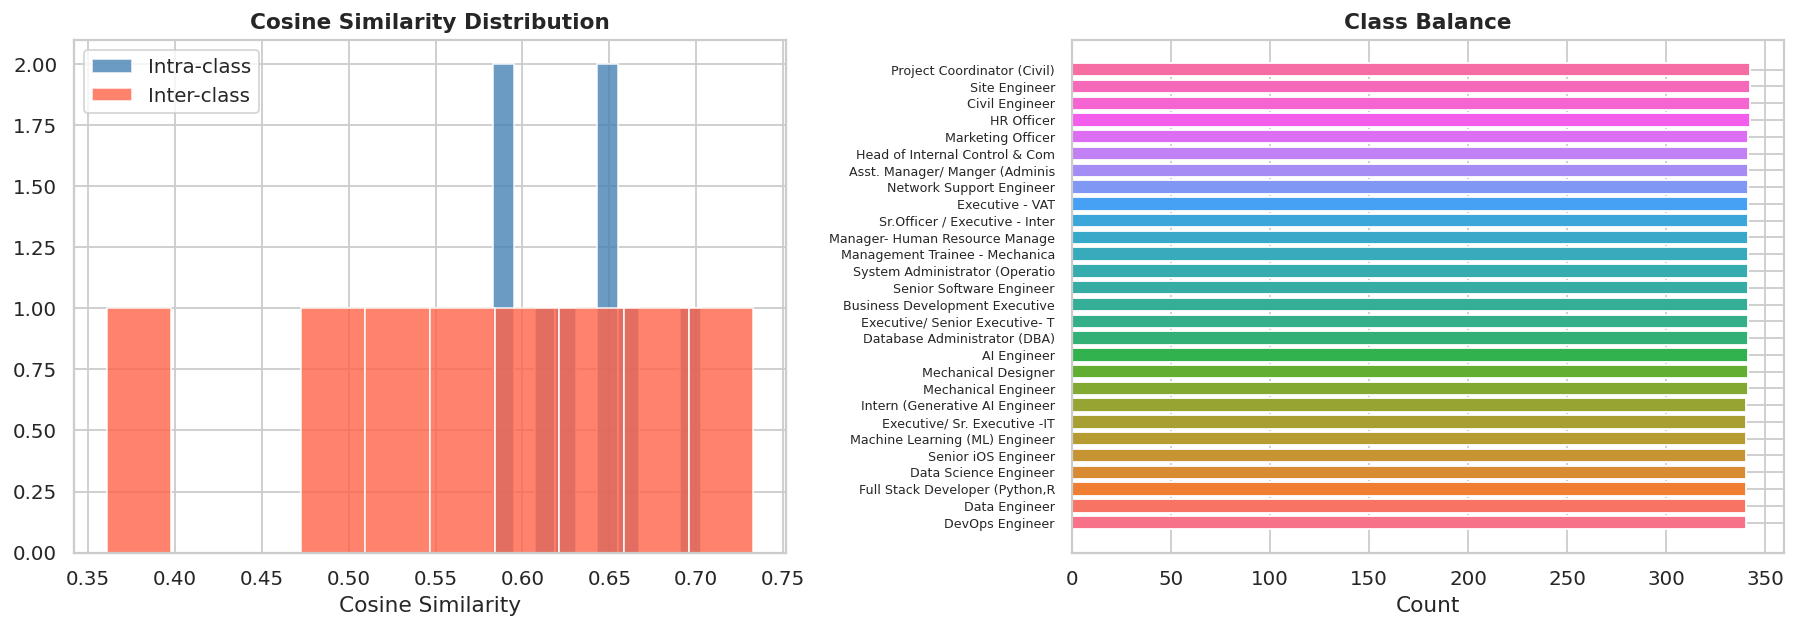

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

print('📊 Dataset Quality Metrics (Pre-Training)')
print('='*55)

intra_sims, inter_sims = [], []
sample_classes = np.random.choice(NUM_CLASSES, size=8, replace=False)

for cls in sample_classes:
    cls_vecs = X_embeddings[y_labels == cls]
    if len(cls_vecs) < 2:
        continue
    sample = cls_vecs[np.random.choice(len(cls_vecs), min(50, len(cls_vecs)), replace=False)]
    sim_mat = cosine_similarity(sample)
    np.fill_diagonal(sim_mat, 0)
    intra_sims.append(sim_mat.sum() / (len(sample)*(len(sample)-1)))

idx_a = np.random.choice(len(X_embeddings), 200)
idx_b = np.random.choice(len(X_embeddings), 200)
for a, b in zip(idx_a, idx_b):
    if y_labels[a] != y_labels[b]:
        inter_sims.append(float(cosine_similarity(
            X_embeddings[a:a+1], X_embeddings[b:b+1]
        )[0][0]))

print(f'  Avg intra-class cosine similarity : {np.mean(intra_sims):.4f}')
print(f'  Avg inter-class cosine similarity : {np.mean(inter_sims):.4f}')
print(f'  Separability ratio                : {np.mean(intra_sims)/np.mean(inter_sims):.3f}x')
print(f'  Total samples  : {len(df):,}')
print(f'  Total classes  : {NUM_CLASSES}')
print(f'  Avg class size : {len(df)/NUM_CLASSES:.1f}')
print(f'  Min class size : {pd.Series(y_labels).value_counts().min()}')
print(f'  Max class size : {pd.Series(y_labels).value_counts().max()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(intra_sims, bins=10, color='steelblue', alpha=0.8, label='Intra-class')
axes[0].hist(inter_sims[:len(intra_sims)], bins=10, color='tomato', alpha=0.8, label='Inter-class')
axes[0].set_title('Cosine Similarity Distribution', fontweight='bold')
axes[0].set_xlabel('Cosine Similarity')
axes[0].legend()

class_counts = pd.Series(y_labels).value_counts().sort_values()
axes[1].barh(range(len(class_counts)), class_counts.values,
             color=sns.color_palette('husl', len(class_counts)))
axes[1].set_yticks(range(len(class_counts)))
axes[1].set_yticklabels([le.classes_[i][:30] for i in class_counts.index], fontsize=7)
axes[1].set_title('Class Balance', fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/dataset_analysis.png', bbox_inches='tight')
plt.show()

## ✂️ STEP 10 — Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_embeddings, y_labels,
    test_size=0.20,
    random_state=42,
    stratify=y_labels
)

print(f'Train set: {X_train.shape[0]:,} samples')
print(f'Test set : {X_test.shape[0]:,} samples')
print(f'Split    : 80/20 stratified')

np.save(f'{MODEL_DIR}/X_train.npy', X_train)
np.save(f'{MODEL_DIR}/X_test.npy',  X_test)
np.save(f'{MODEL_DIR}/y_train.npy', y_train)
np.save(f'{MODEL_DIR}/y_test.npy',  y_test)
print('✅ Splits saved to Drive.')

Train set: 7,635 samples
Test set : 1,909 samples
Split    : 80/20 stratified
✅ Splits saved to Drive.


## 🏋️ STEP 11 — Model Training (All Classifiers)

In [ ]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train, predict, and return full evaluation metrics."""
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0
    y_pred = model.predict(X_te)
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    return {
        'Model': name,
        'Accuracy': round(acc * 100, 2),
        'Precision': round(prec * 100, 2),
        'Recall': round(rec * 100, 2),
        'F1-Score': round(f1 * 100, 2),
        'Train Time (s)': round(train_time, 2),
        '_model': model,
        '_y_pred': y_pred
    }


classifiers = {
    'SVM (RBF)': CalibratedClassifierCV(
        SVC(kernel='rbf', C=10, gamma='scale', decision_function_shape='ovr'), cv=3
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_split=2,
        n_jobs=-1, random_state=42
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        use_label_encoder=False, eval_metric='mlogloss',
        tree_method='hist', random_state=42, n_jobs=-1
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        num_leaves=63, random_state=42, n_jobs=-1, verbose=-1
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=10, multi_class='multinomial',
        solver='lbfgs', random_state=42, n_jobs=-1
    ),
}

results = []
trained_models = {}

for name, clf in classifiers.items():
    print(f'  ⚙️  Training {name}...')
    res = evaluate_model(name, clf, X_train, y_train, X_test, y_test)
    trained_models[name] = res.pop('_model')
    res.pop('_y_pred')
    results.append(res)
    print(f'     Accuracy={res["Accuracy"]}%  F1={res["F1-Score"]}%  ({res["Train Time (s)"]}s)')

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print('\n✅ All models trained!')

  ⚙️  Training SVM (RBF)...
     Accuracy=80.25%  F1=79.09%  (42.46s)
  ⚙️  Training Random Forest...
     Accuracy=52.12%  F1=52.81%  (111.94s)
  ⚙️  Training XGBoost...
     Accuracy=76.64%  F1=77.06%  (913.83s)
  ⚙️  Training LightGBM...
     Accuracy=79.94%  F1=80.39%  (424.75s)
  ⚙️  Training Logistic Regression...
     Accuracy=90.41%  F1=90.38%  (7.6s)

✅ All models trained!


## 🏆 STEP 12 — Voting Ensemble (Best Model)

In [ ]:
print('⏳ Training Voting Ensemble (SVM + XGBoost + LightGBM)...')

ensemble = VotingClassifier(
    estimators=[
        ('svm',  trained_models['SVM (RBF)']),
        ('xgb',  trained_models['XGBoost']),
        ('lgbm', trained_models['LightGBM']),
    ],
    voting='soft'
)

t0 = time.time()
ensemble.fit(X_train, y_train)
ens_time = time.time() - t0

ens_pred = ensemble.predict(X_test)
ens_acc  = accuracy_score(y_test, ens_pred) * 100
ens_f1   = f1_score(y_test, ens_pred, average='weighted', zero_division=0) * 100
ens_prec = precision_score(y_test, ens_pred, average='weighted', zero_division=0) * 100
ens_rec  = recall_score(y_test, ens_pred, average='weighted', zero_division=0) * 100

results_df = pd.concat([results_df, pd.DataFrame([{
    'Model': '⭐ Voting Ensemble',
    'Accuracy': round(ens_acc, 2),
    'Precision': round(ens_prec, 2),
    'Recall': round(ens_rec, 2),
    'F1-Score': round(ens_f1, 2),
    'Train Time (s)': round(ens_time, 2)
}])], ignore_index=True)

trained_models['Voting Ensemble'] = ensemble

best_row = results_df.loc[results_df['Accuracy'].idxmax()]
BEST_MODEL_NAME = best_row['Model'].replace('⭐ ', '')
BEST_CLF = trained_models.get(BEST_MODEL_NAME, ensemble)

print(f'\n✅ Ensemble trained!  Accuracy={ens_acc:.2f}%  F1={ens_f1:.2f}%')
print(f'🏆 Best model: {best_row["Model"]}  ({best_row["Accuracy"]}%)')

# Save best model to Drive
joblib.dump(BEST_CLF, f'{MODEL_DIR}/best_classifier.pkl')
joblib.dump(le,       f'{MODEL_DIR}/label_encoder.pkl')
print('💾 Best model + LabelEncoder saved to Drive.')

⏳ Training Voting Ensemble (SVM + XGBoost + LightGBM)...

✅ Ensemble trained!  Accuracy=81.93%  F1=82.22%
🏆 Best model: Logistic Regression  (90.41%)
💾 Best model + LabelEncoder saved to Drive.


## 📈 STEP 13 — Evaluation Metrics Dashboard

,Model,Accuracy,Precision,Recall,F1-Score,Train Time (s)
0,Logistic Regression,90.41%,90.50%,90.41%,90.38%,7.600000
1,SVM (RBF),80.25%,79.94%,80.25%,79.09%,42.460000
2,LightGBM,79.94%,81.26%,79.94%,80.39%,424.750000
3,XGBoost,76.64%,78.02%,76.64%,77.06%,913.830000
4,Random Forest,52.12%,54.23%,52.12%,52.81%,111.940000
5,⭐ Voting Ensemble,81.93%,82.86%,81.93%,82.22%,1360.570000


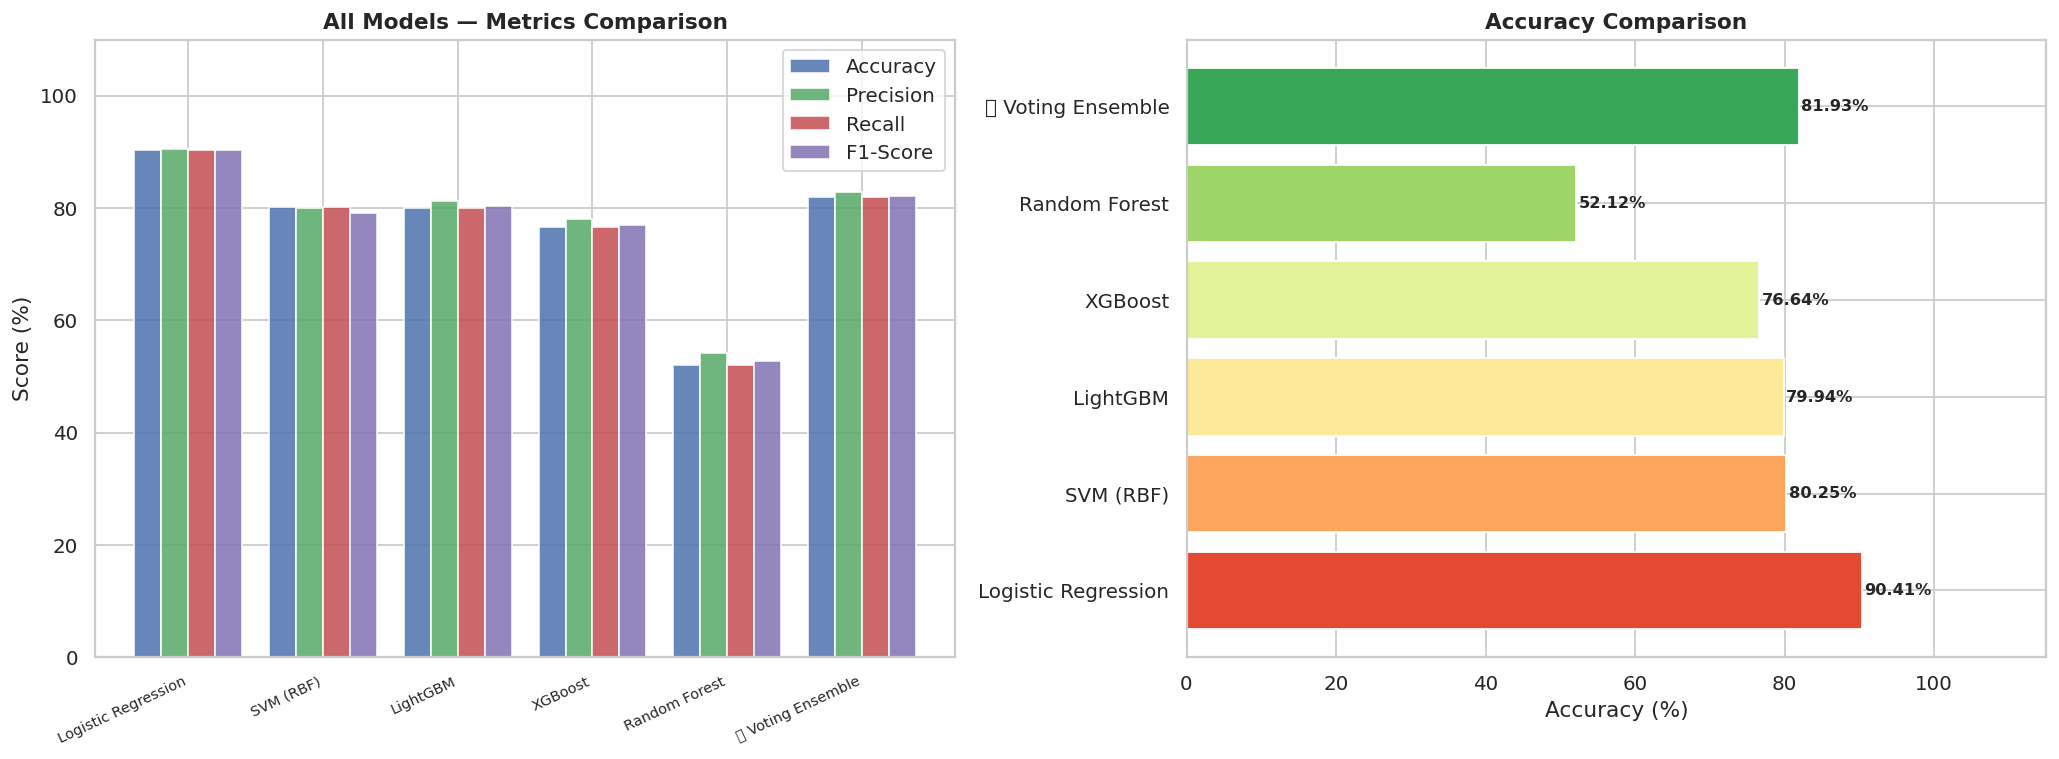

In [ ]:
display(HTML('<h3>📊 Model Comparison — All Classifiers</h3>'))
styled = results_df.style \
    .highlight_max(subset=['Accuracy','F1-Score','Precision','Recall'], color='lightgreen') \
    .format({'Accuracy':'{:.2f}%','Precision':'{:.2f}%','Recall':'{:.2f}%','F1-Score':'{:.2f}%'})
display(styled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics = ['Accuracy','Precision','Recall','F1-Score']
x = np.arange(len(results_df))
width = 0.2
colors = ['#4C72B0','#55A868','#C44E52','#8172B2']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    axes[0].bar(x + i*width, results_df[metric], width,
                label=metric, color=color, alpha=0.85)
axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(results_df['Model'], rotation=25, ha='right', fontsize=8)
axes[0].set_ylabel('Score (%)')
axes[0].set_ylim(0, 110)
axes[0].set_title('All Models — Metrics Comparison', fontweight='bold')
axes[0].legend()

bars = axes[1].barh(
    results_df['Model'],
    results_df['Accuracy'],
    color=sns.color_palette('RdYlGn', len(results_df))
)
for bar, val in zip(bars, results_df['Accuracy']):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}%', va='center', fontsize=9, fontweight='bold')
axes[1].set_xlim(0, 115)
axes[1].set_title('Accuracy Comparison', fontweight='bold')
axes[1].set_xlabel('Accuracy (%)')

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/model_comparison.png', bbox_inches='tight')
plt.show()

## 🔢 STEP 14 — Advanced Metrics: Top-K Accuracy & MRR

⏳ Computing Top-K and MRR for best model...

  ADVANCED METRICS — Logistic Regression
  Top-1     : 90.41%
  Top-3     : 96.39%
  Top-5     : 98.11%
  MRR       : 0.9369  (max=1.0)


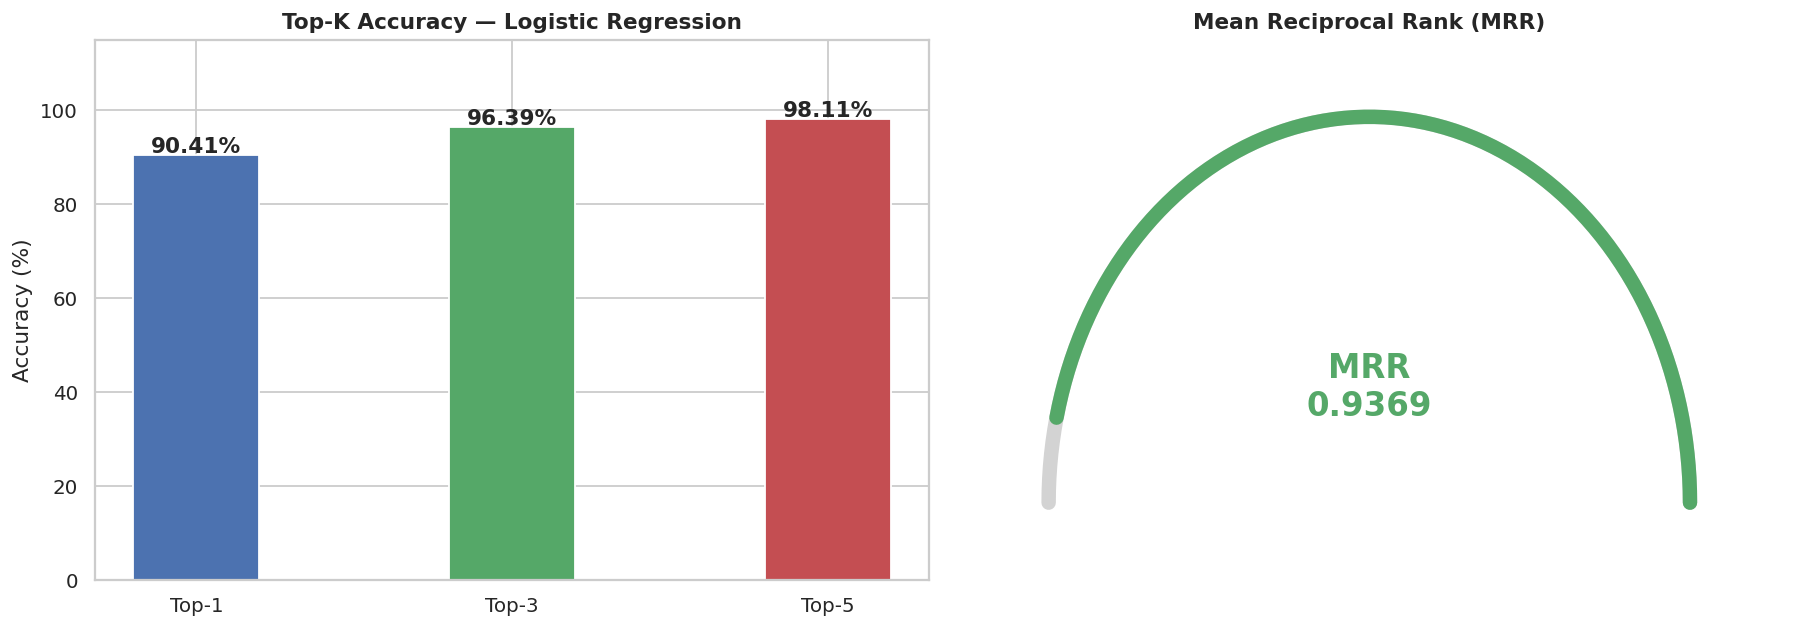

In [ ]:
def top_k_accuracy(model, X, y_true, k_list=[1,3,5]):
    """Calculate Top-K accuracy using predict_proba."""
    proba = model.predict_proba(X)
    results = {}
    for k in k_list:
        top_k_preds = np.argsort(proba, axis=1)[:, -k:]
        correct = sum(y_true[i] in top_k_preds[i] for i in range(len(y_true)))
        results[f'Top-{k}'] = round(correct / len(y_true) * 100, 2)
    return results


def mean_reciprocal_rank(model, X, y_true):
    """
    MRR = 1/N * sum(1/rank_i)
    Perfect MRR = 1.0 (correct answer always ranked #1)
    """
    proba = model.predict_proba(X)
    rr_list = []
    for i in range(len(y_true)):
        ranked = np.argsort(proba[i])[::-1]
        rank   = np.where(ranked == y_true[i])[0]
        rr_list.append(1.0 / (rank[0] + 1) if len(rank) > 0 else 0.0)
    return round(np.mean(rr_list), 4)


print('⏳ Computing Top-K and MRR for best model...')
topk = top_k_accuracy(BEST_CLF, X_test, y_test)
mrr  = mean_reciprocal_rank(BEST_CLF, X_test, y_test)

print('\n' + '='*50)
print(f'  ADVANCED METRICS — {BEST_MODEL_NAME}')
print('='*50)
for k, v in topk.items():
    print(f'  {k:10s}: {v:.2f}%')
print(f'  MRR       : {mrr:.4f}  (max=1.0)')
print('='*50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

k_labels = list(topk.keys())
k_values = list(topk.values())
bars = axes[0].bar(k_labels, k_values,
                   color=['#4C72B0','#55A868','#C44E52'], width=0.4)
for bar, val in zip(bars, k_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.2f}%', ha='center', fontweight='bold')
axes[0].set_ylim(0, 115)
axes[0].set_title(f'Top-K Accuracy — {BEST_MODEL_NAME}', fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')

theta = np.linspace(0, np.pi, 100)
axes[1].plot(np.cos(theta), np.sin(theta), 'lightgray', lw=8)
axes[1].plot(np.cos(theta[:int(mrr*100)]), np.sin(theta[:int(mrr*100)]),
             '#55A868', lw=8)
axes[1].text(0, 0.3, f'MRR\n{mrr:.4f}', ha='center', va='center',
             fontsize=18, fontweight='bold', color='#55A868')
axes[1].set_xlim(-1.3, 1.3)
axes[1].set_ylim(-0.2, 1.2)
axes[1].axis('off')
axes[1].set_title('Mean Reciprocal Rank (MRR)', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/advanced_metrics.png', bbox_inches='tight')
plt.show()

## 🔥 STEP 15 — Confusion Matrix & Per-Class Analysis

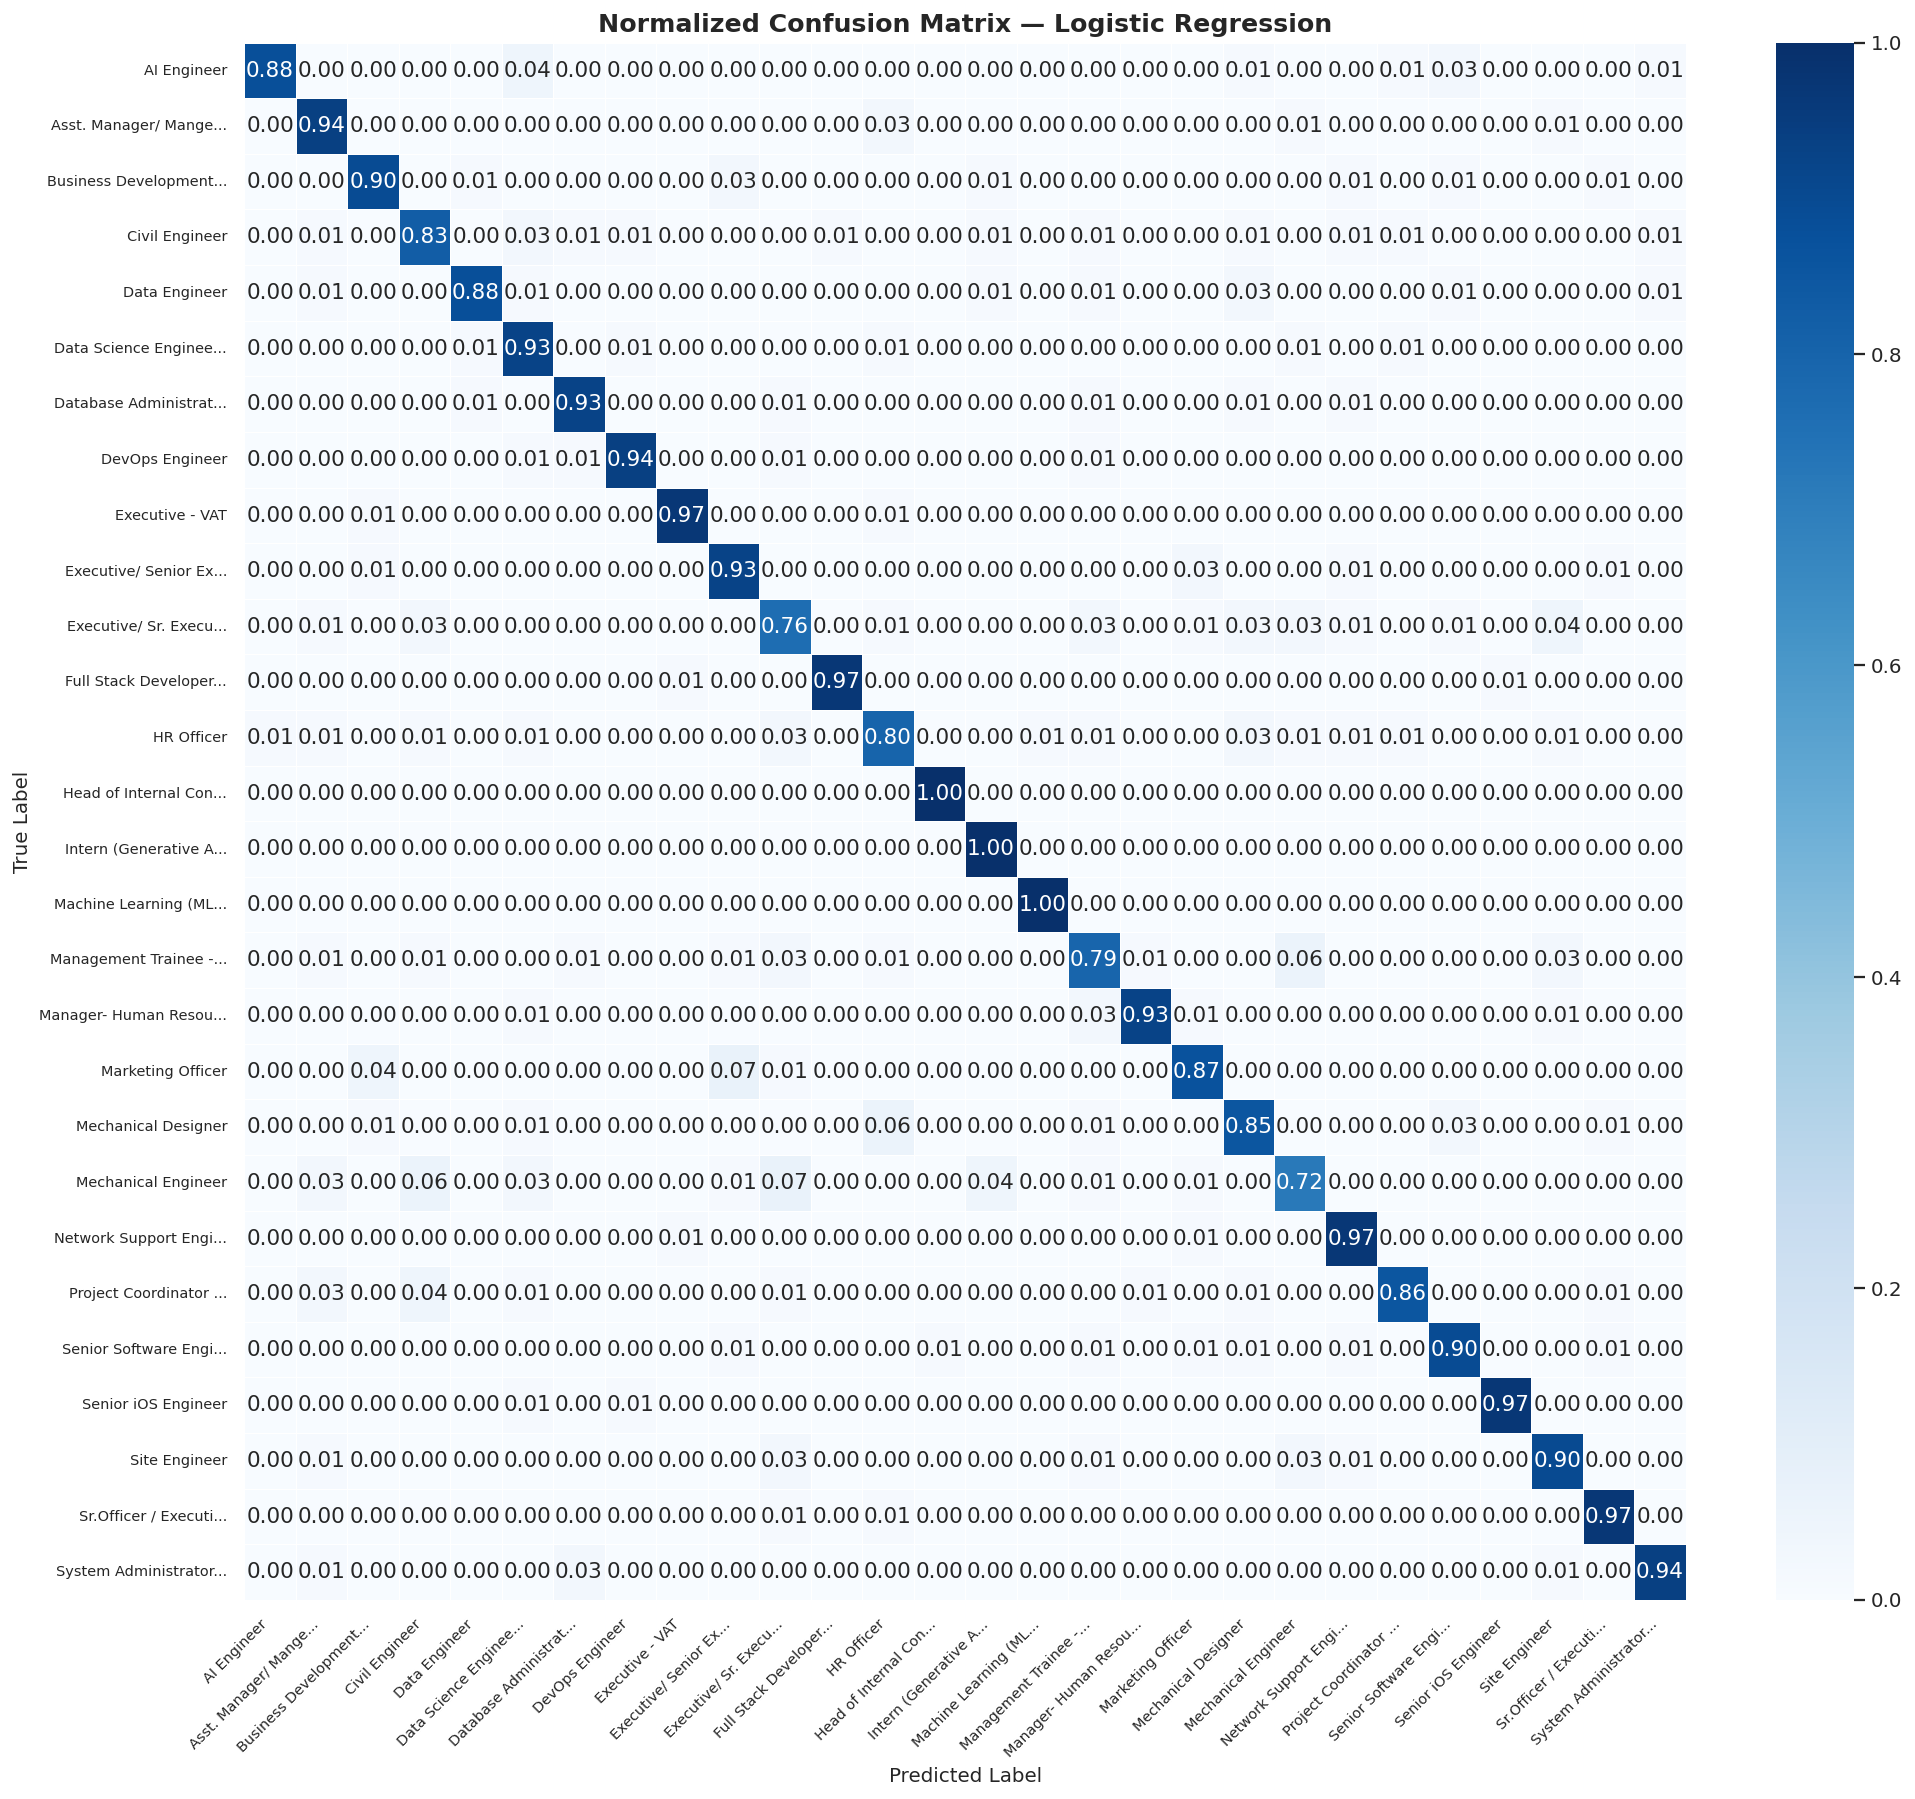


📋 Per-Class Classification Report:
                                                                                         precision    recall  f1-score   support

                                                                            AI Engineer       0.98      0.88      0.93        68
                                                 Asst. Manager/ Manger (Administrative)       0.85      0.94      0.90        68
                                                         Business Development Executive       0.91      0.90      0.90        68
                                                                         Civil Engineer       0.84      0.83      0.83        69
                                                                          Data Engineer       0.95      0.88      0.92        68
                                                                  Data Science Engineer       0.82      0.93      0.87        68
                                                           D

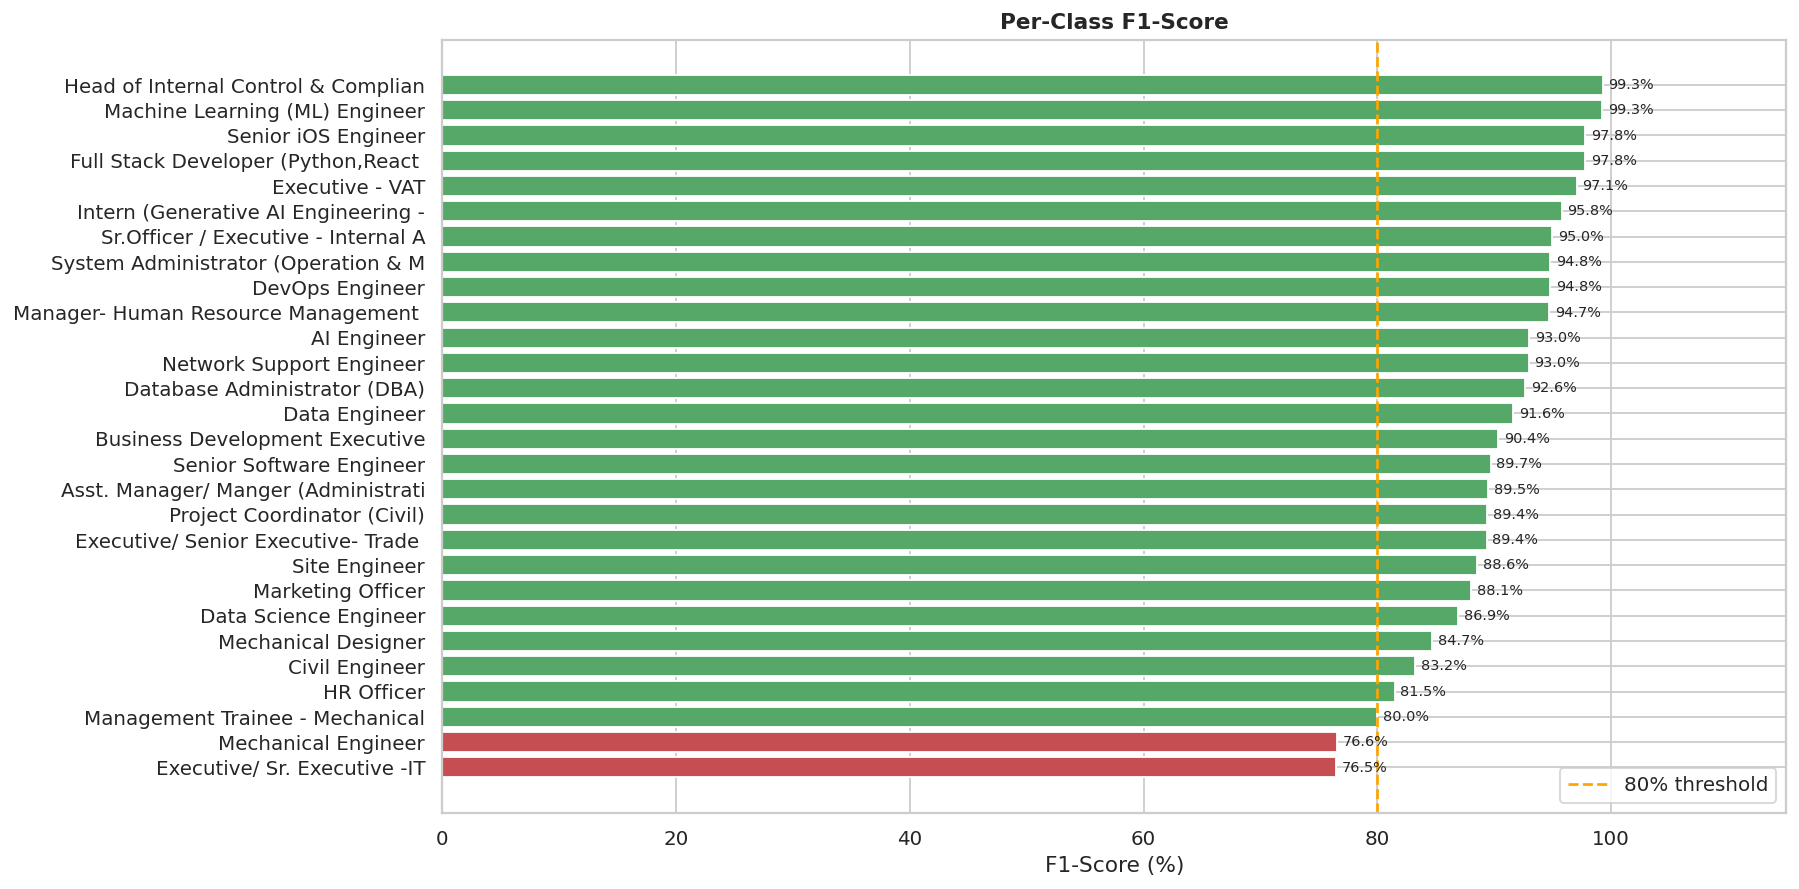

In [ ]:
y_pred_best = BEST_CLF.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
short_labels = [lbl[:20] + '...' if len(lbl) > 20 else lbl for lbl in le.classes_]

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=short_labels, yticklabels=short_labels,
            ax=ax, linewidths=0.3)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_title(f'Normalized Confusion Matrix — {BEST_MODEL_NAME}',
             fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/confusion_matrix.png', bbox_inches='tight')
plt.show()

print('\n📋 Per-Class Classification Report:')
report = classification_report(y_test, y_pred_best,
                                target_names=le.classes_, zero_division=0)
print(report)

report_dict = classification_report(y_test, y_pred_best,
                                     target_names=le.classes_,
                                     output_dict=True, zero_division=0)
per_class_f1 = {k: v['f1-score'] for k, v in report_dict.items()
                if k not in ['accuracy','macro avg','weighted avg']}

fig, ax = plt.subplots(figsize=(14, 7))
classes_sorted = sorted(per_class_f1, key=per_class_f1.get)
f1_vals = [per_class_f1[c] for c in classes_sorted]
colors  = ['#C44E52' if v < 0.8 else '#55A868' for v in f1_vals]
bars = ax.barh([c[:35] for c in classes_sorted], [v*100 for v in f1_vals], color=colors)
for bar, val in zip(bars, f1_vals):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=8)
ax.set_xlim(0, 115)
ax.set_title('Per-Class F1-Score', fontweight='bold')
ax.set_xlabel('F1-Score (%)')
ax.axvline(80, color='orange', linestyle='--', label='80% threshold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/per_class_f1.png', bbox_inches='tight')
plt.show()

## 🔄 STEP 16 — 5-Fold Cross-Validation

⏳ Running 5-Fold Stratified Cross-Validation on best model...

  5-FOLD CV — Logistic Regression
  Fold Accuracies : ['90.36%', '89.94%', '90.89%', '91.51%', '91.19%']
  CV Accuracy     : 90.78% ± 0.57%
  CV F1 (weighted): 90.77% ± 0.56%


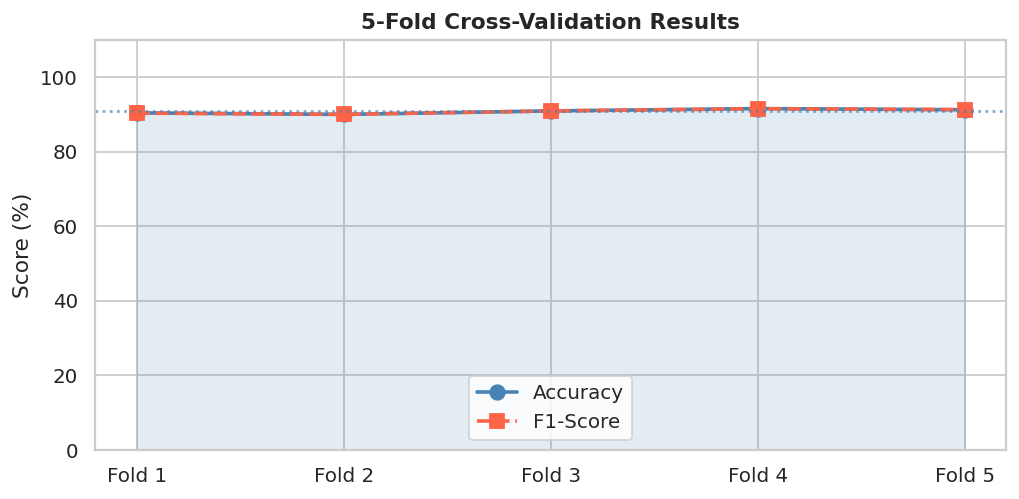

In [ ]:
print('⏳ Running 5-Fold Stratified Cross-Validation on best model...')

skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc = cross_val_score(BEST_CLF, X_embeddings, y_labels,
                          cv=skf, scoring='accuracy', n_jobs=-1)
cv_f1  = cross_val_score(BEST_CLF, X_embeddings, y_labels,
                          cv=skf, scoring='f1_weighted', n_jobs=-1)

print('\n' + '='*50)
print(f'  5-FOLD CV — {BEST_MODEL_NAME}')
print('='*50)
print(f'  Fold Accuracies : {[f"{v*100:.2f}%" for v in cv_acc]}')
print(f'  CV Accuracy     : {cv_acc.mean()*100:.2f}% ± {cv_acc.std()*100:.2f}%')
print(f'  CV F1 (weighted): {cv_f1.mean()*100:.2f}% ± {cv_f1.std()*100:.2f}%')
print('='*50)

fig, ax = plt.subplots(figsize=(8, 4))
folds = [f'Fold {i+1}' for i in range(5)]
ax.plot(folds, cv_acc*100, 'o-', color='steelblue', lw=2, ms=8, label='Accuracy')
ax.plot(folds, cv_f1*100,  's--', color='tomato',   lw=2, ms=8, label='F1-Score')
ax.fill_between(folds, cv_acc*100, alpha=0.15, color='steelblue')
ax.axhline(cv_acc.mean()*100, color='steelblue', linestyle=':', alpha=0.7)
ax.set_ylim(0, 110)
ax.set_title('5-Fold Cross-Validation Results', fontweight='bold')
ax.set_ylabel('Score (%)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/cross_validation.png', bbox_inches='tight')
plt.show()

## 🗺 STEP 17 — Job Role Skill Map (from Job Dataset)

In [ ]:
def build_job_skill_map(job_df: pd.DataFrame) -> dict:
    """
    Returns: {title: {exp_level: [skills], 'all': [skills]}}
    """
    job_map = {}
    for _, row in job_df.dropna(subset=['Title','Skills']).iterrows():
        title  = str(row['Title']).strip()
        level  = str(row.get('ExperienceLevel', 'General')).strip()
        skills = [s.strip() for s in str(row['Skills']).split(';') if s.strip()]
        if title not in job_map:
            job_map[title] = {'all': set()}
        job_map[title]['all'].update(skills)
        if level not in job_map[title]:
            job_map[title][level] = set()
        job_map[title][level].update(skills)
    for title in job_map:
        for lvl in job_map[title]:
            job_map[title][lvl] = sorted(job_map[title][lvl])
    return job_map

JOB_SKILL_MAP = build_job_skill_map(jobrole_df)
print(f'✅ Job Skill Map: {len(JOB_SKILL_MAP)} unique job titles')

✅ Job Skill Map: 218 unique job titles


## 🧩 STEP 18 — Skill Gap Analysis Engine

In [ ]:
def find_best_job_match(predicted_label: str, job_skill_map: dict) -> tuple:
    pred_words = set(predicted_label.lower().split())
    best_title, best_score = None, -1
    for title in job_skill_map:
        title_words = set(title.lower().split())
        overlap = len(pred_words & title_words) / max(len(pred_words | title_words), 1)
        if overlap > best_score:
            best_score = overlap
            best_title = title
    return best_title, best_score


def analyze_skill_gap(user_skills: list, predicted_job: str,
                       job_skill_map: dict, experience_level: str = 'Experienced') -> dict:
    user_skills_lower = {s.lower().strip() for s in user_skills if s}
    best_title, match_score = find_best_job_match(predicted_job, job_skill_map)
    if best_title is None:
        return {'error': 'No matching job found in database'}
    job_data = job_skill_map.get(best_title, {})
    req_skills_raw = job_data.get(experience_level,
                                   job_data.get('Experienced',
                                   job_data.get('all', [])))
    req_skills     = {s.lower().strip() for s in req_skills_raw}
    matched_skills = sorted(user_skills_lower & req_skills)
    missing_skills = sorted(req_skills - user_skills_lower)
    extra_skills   = sorted(user_skills_lower - req_skills)
    match_pct      = len(matched_skills) / max(len(req_skills), 1) * 100
    return {
        'matched_job_title'  : best_title,
        'match_confidence'   : round(match_score * 100, 1),
        'experience_level'   : experience_level,
        'user_skills'        : sorted(user_skills_lower),
        'required_skills'    : sorted(req_skills),
        'matched_skills'     : matched_skills,
        'missing_skills'     : missing_skills,
        'extra_skills'       : extra_skills,
        'skill_match_%'      : round(match_pct, 1),
        'skills_to_improve'  : matched_skills[:6],
        'top_recommendations': missing_skills[:12],
    }

print('✅ Skill Gap Analysis engine ready.')

✅ Skill Gap Analysis engine ready.


## 📄 STEP 19 — PDF Resume Parser

In [ ]:
def extract_text_from_pdf(pdf_path: str) -> str:
    """
    Extract text from PDF using pdfplumber.
    Falls back to pytesseract OCR for scanned PDFs.
    """
    text = ''
    try:
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    text += page_text + '\n'
    except Exception as e:
        print(f'pdfplumber error: {e}')

    if len(text.strip()) < 100:
        try:
            import pytesseract
            from PIL import Image
            import fitz
            doc = fitz.open(pdf_path)
            for page in doc:
                pix = page.get_pixmap(dpi=200)
                img = Image.frombytes('RGB', [pix.width, pix.height], pix.samples)
                text += pytesseract.image_to_string(img) + '\n'
            print('   ℹ️  Used OCR fallback for scanned PDF')
        except Exception as e:
            print(f'OCR fallback error: {e}')
    return text


def predict_from_pdf(pdf_path: str, classifier, sbert_model,
                      label_encoder, skill_dict, job_skill_map,
                      top_k: int = 3,
                      experience_level: str = 'Experienced') -> dict:
    """
    Full end-to-end SkillLens pipeline for a user-uploaded PDF resume.
    """
    print(f'  📄 Parsing PDF: {pdf_path}')
    raw_text = extract_text_from_pdf(pdf_path)

    if not raw_text.strip():
        return {'error': 'Could not extract text from PDF'}

    print(f'     Extracted {len(raw_text)} characters')

    cleaned          = clean_text(raw_text)
    extracted_skills = extract_skills_from_text(raw_text, skill_dict)
    print(f'     Extracted {len(extracted_skills)} skills')

    embedding = sbert_model.encode(
        [cleaned], normalize_embeddings=True
    ).astype('float32')

    D, I = faiss_index.search(embedding, k=5)
    faiss_top_jobs = [label_encoder.classes_[y_labels[idx]] for idx in I[0]]

    proba       = classifier.predict_proba(embedding)[0]
    top_k_idx   = np.argsort(proba)[::-1][:top_k]
    top_k_jobs  = [(label_encoder.classes_[i], round(proba[i]*100, 2)) for i in top_k_idx]
    predicted_job = top_k_jobs[0][0]
    confidence    = top_k_jobs[0][1]

    gap = analyze_skill_gap(extracted_skills, predicted_job,
                             job_skill_map, experience_level)

    return {
        'raw_text_length'   : len(raw_text),
        'extracted_skills'  : extracted_skills,
        'predicted_job_role': predicted_job,
        'confidence_%'      : confidence,
        'top_k_predictions' : top_k_jobs,
        'faiss_similar_jobs': faiss_top_jobs,
        'skill_gap_analysis': gap,
    }

print('✅ PDF pipeline ready.')

✅ PDF pipeline ready.


## 🚀 STEP 20 — USER UPLOAD & PREDICTION

> **Upload your resume PDF to Colab first, then set `PDF_PATH` below.**
>
> To upload: Click the 📁 folder icon on the left panel → Upload button → select your PDF
>
> Or store your PDF in Drive: `/content/drive/MyDrive/resume_project/my_resume.pdf`

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ✏️  Option A — PDF stored in your Google Drive folder:
PDF_PATH = f'{DRIVE_BASE}/my_resume.pdf'

# ✏️  Option B — PDF uploaded directly to Colab session:
# PDF_PATH = '/content/my_resume.pdf'

EXPERIENCE_LEVEL = 'Experienced'   # 'Fresher' | 'Experienced' | 'Senior-Level'
TOP_K            = 3
# ─────────────────────────────────────────────────────────────────────────────

if not os.path.exists(PDF_PATH):
    print(f'❌ File not found: {PDF_PATH}')
    print('   → Upload your PDF to Drive at: /content/drive/MyDrive/resume_project/')
    print('   → Or change PDF_PATH to where your file is.')
else:
    print('🚀 Running SkillLens AI Pipeline...\n')
    result = predict_from_pdf(
        PDF_PATH, BEST_CLF, sbert, le,
        SKILL_DICT, JOB_SKILL_MAP,
        top_k=TOP_K,
        experience_level=EXPERIENCE_LEVEL
    )
    print('\n✅ Analysis complete!')

❌ File not found: /content/drive/MyDrive/resume_project/my_resume.pdf
   → Upload your PDF to Drive at: /content/drive/MyDrive/resume_project/
   → Or change PDF_PATH to where your file is.


In [ ]:
# ── SkillLens AI — Interactive PDF Upload & Prediction ────────────────────────
import ipywidgets as widgets
from IPython.display import display, HTML

# ── Settings ──────────────────────────────────────────────────────────────────
TOP_K = 3
# ─────────────────────────────────────────────────────────────────────────────

# ── Step 1: Experience level dropdown ─────────────────────────────────────────
exp_dropdown = widgets.Dropdown(
    options=['Fresher', 'Entry-Level', 'Junior', 'Mid-Level',
             'Mid-Senior Level', 'Experienced', 'Senior-Level', 'Lead'],
    value='Experienced',
    description='Experience:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='320px', margin='0 0 12px 0')
)

# ── Step 2: PDF upload button ─────────────────────────────────────────────────
upload_widget = widgets.FileUpload(
    accept='.pdf',
    multiple=False,
    description='📄 Upload Resume PDF',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='320px')
)

# ── Step 3: Analyse button ────────────────────────────────────────────────────
run_btn = widgets.Button(
    description='🚀 Analyse Resume',
    button_style='success',
    layout=widgets.Layout(width='200px', height='38px', margin='12px 0 0 0')
)

# ── Status label + output area ────────────────────────────────────────────────
status_label = widgets.HTML(
    value='<span style="color:gray;font-size:13px">'
          '⬆️  Select experience level → Upload PDF → Click Analyse</span>'
)
out = widgets.Output()

# ── What happens when button is clicked ───────────────────────────────────────
def on_run_clicked(b):
    global result
    out.clear_output()

    # Check if user uploaded a file
    if len(upload_widget.value) == 0:
        with out:
            display(HTML('<p style="color:#C44E52;font-size:14px">'
                         '❌ No file uploaded! Please click "Upload Resume PDF" '
                         'and select your PDF first.</p>'))
        return

    # Read the uploaded file
    file_name    = list(upload_widget.value.keys())[0]
    file_content = list(upload_widget.value.values())[0]['content']

    # Only allow PDF
    if not file_name.lower().endswith('.pdf'):
        with out:
            display(HTML('<p style="color:#C44E52;font-size:14px">'
                         '❌ Please upload a .pdf file only.</p>'))
        return

    # Save file to /tmp/ so pdfplumber can read it
    tmp_path = f'/tmp/{file_name}'
    with open(tmp_path, 'wb') as f:
        f.write(file_content)

    selected_level = exp_dropdown.value
    status_label.value = (
        f'<span style="color:#378ADD;font-size:13px">'
        f'⏳ Analysing <b>{file_name}</b> — Level: <b>{selected_level}</b>...</span>'
    )

    with out:
        print(f'📄 File     : {file_name}')
        print(f'👤 Level    : {selected_level}')
        print(f'📦 Size     : {len(file_content):,} bytes')
        print()
        print('🚀 Running SkillLens AI Pipeline...\n')

        try:
            result = predict_from_pdf(
                tmp_path, BEST_CLF, sbert, le,
                SKILL_DICT, JOB_SKILL_MAP,
                top_k=TOP_K,
                experience_level=selected_level
            )

            # Also save the PDF to your Drive
            drive_pdf_path = f'{DRIVE_BASE}/{file_name}'
            with open(drive_pdf_path, 'wb') as f:
                f.write(file_content)

            print('\n✅ Analysis complete!')
            print(f'💾 PDF saved to Drive: {drive_pdf_path}')
            print('\n👉 Now run STEP 21 to see the full report.')

            status_label.value = (
                f'<span style="color:#1e8449;font-size:13px">'
                f'✅ Done! Predicted: <b>{result["predicted_job_role"]}</b> '
                f'({result["confidence_%"]}% confidence) '
                f'— Run STEP 21 for full report.</span>'
            )

        except Exception as e:
            print(f'\n❌ Error: {e}')
            print('   Make sure you ran all steps 0–19 before this.')
            status_label.value = (
                f'<span style="color:#C44E52;font-size:13px">❌ Error: {str(e)[:100]}</span>'
            )

run_btn.on_click(on_run_clicked)

# ── Show the UI ───────────────────────────────────────────────────────────────
display(HTML(
    '<div style="font-weight:600;font-size:15px;margin-bottom:8px">'
    '🎯 SkillLens AI — Resume Analyser</div>'
    '<div style="font-size:12px;color:gray;margin-bottom:14px">'
    '1️⃣ Pick experience level &nbsp;|&nbsp; '
    '2️⃣ Upload your PDF &nbsp;|&nbsp; '
    '3️⃣ Click Analyse Resume</div>'
))
display(exp_dropdown)
display(upload_widget)
display(run_btn)
display(status_label)
display(out)

Dropdown(description='Experience:', index=5, layout=Layout(margin='0 0 12px 0', width='320px'), options=('Fres…

FileUpload(value={}, accept='.pdf', description='📄 Upload Resume PDF', layout=Layout(width='320px'))

Button(button_style='success', description='🚀 Analyse Resume', layout=Layout(height='38px', margin='12px 0 0 0…

HTML(value='<span style="color:gray;font-size:13px">⬆️  Select experience level → Upload PDF → Click Analyse</…

Output()

## 📊 STEP 21 — Display Full Prediction Report

  🎯  SkillLens AI — Resume Analysis Report

📌 PREDICTED JOB ROLE : Business Development Executive
   Confidence         : 51.0%

📊 TOP-3 JOB PREDICTIONS:
   #1  Business Development Executive                 51.00%  ██████████
   #2  Sr.Officer / Executive - Internal Audit        16.97%  ███
   #3  Executive - VAT                                12.81%  ██

🔍 SIMILAR RESUMES (FAISS Top-5):
   → System Administrator (Operation & Maintenance of Server, Storage & Service Desk System)
   → Network Support Engineer
   → Sr.Officer / Executive - Internal Audit
   → Full Stack Developer (Python,React js)
   → Full Stack Developer (Python,React js)

🛠  EXTRACTED SKILLS (31 total):
   Javascript · Cloud · Html5 · Html · Python · Scheduling
   React · Database · Encryption · Java · Machine Learning · Express.Js
   Innovation · Backend · Express · Linux · Storage · Project Management
   Agile · Js · Css · Agile Project Management · Css3 · Ai
   Communication · Node.Js · Data Analysis · E-Commerce 

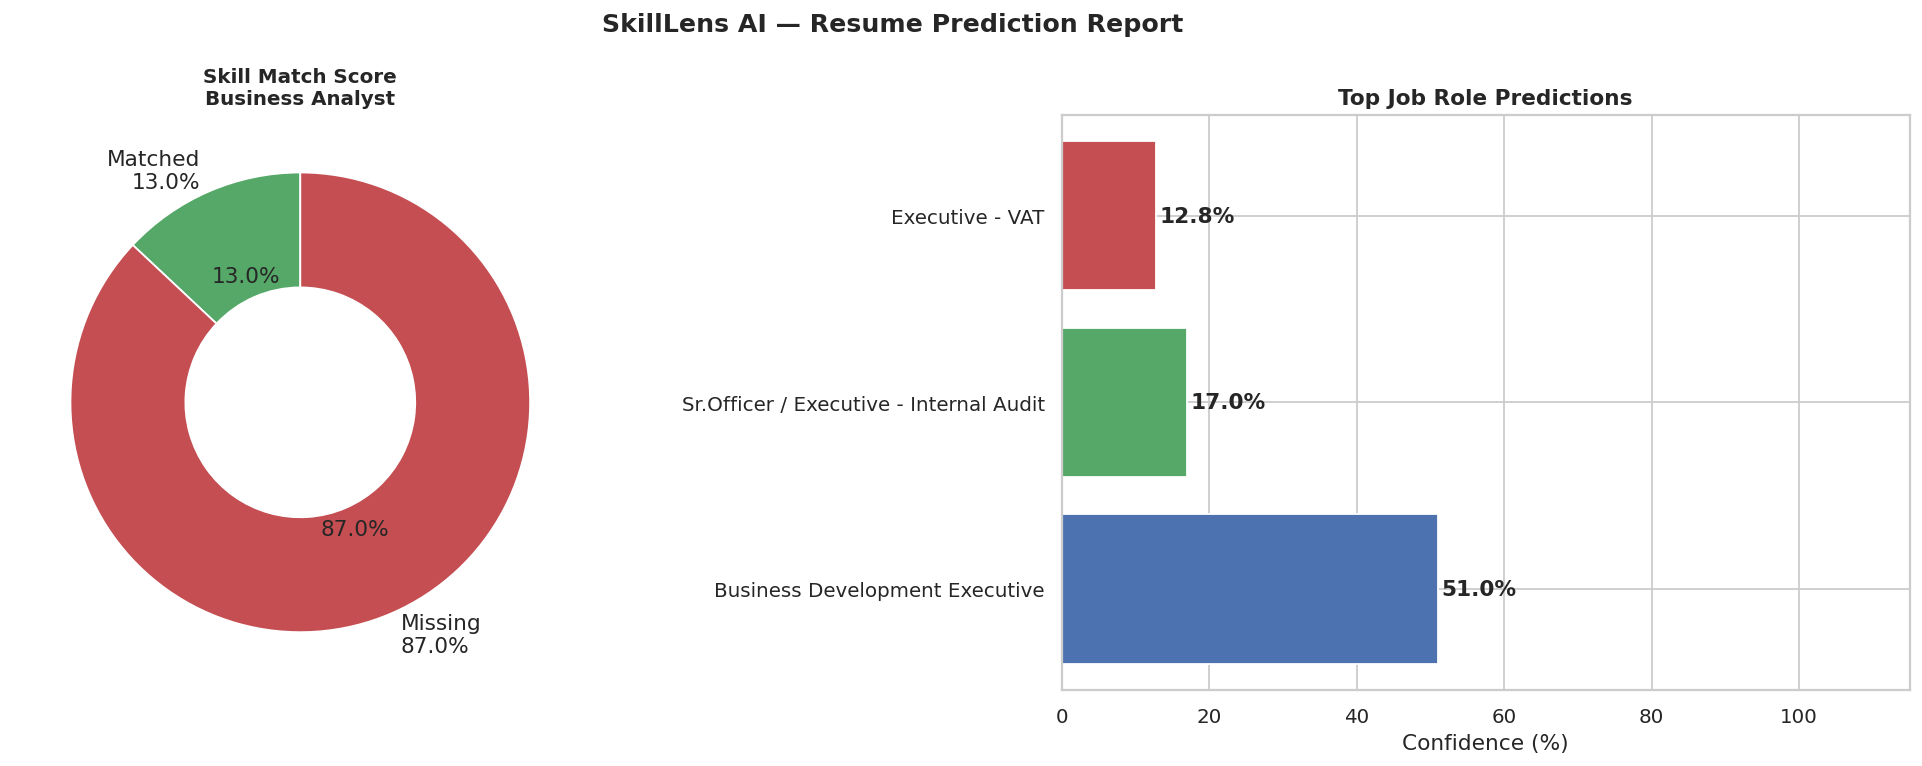

In [ ]:
def display_full_report(result: dict):
    if 'error' in result:
        print(f'❌ Error: {result["error"]}')
        return

    gap = result['skill_gap_analysis']
    sep = '='*65

    print(sep)
    print('  🎯  SkillLens AI — Resume Analysis Report')
    print(sep)
    print(f'\n📌 PREDICTED JOB ROLE : {result["predicted_job_role"]}')
    print(f'   Confidence         : {result["confidence_%"]}%')

    print(f'\n📊 TOP-{len(result["top_k_predictions"])} JOB PREDICTIONS:')
    for rank, (job, conf) in enumerate(result['top_k_predictions'], 1):
        bar = '█' * int(conf / 5)
        print(f'   #{rank}  {job:<45} {conf:>6.2f}%  {bar}')

    print(f'\n🔍 SIMILAR RESUMES (FAISS Top-5):')
    for j in result['faiss_similar_jobs']:
        print(f'   → {j}')

    print(f'\n🛠  EXTRACTED SKILLS ({len(result["extracted_skills"])} total):')
    chunks = [result['extracted_skills'][i:i+6]
              for i in range(0, len(result['extracted_skills']), 6)]
    for chunk in chunks:
        print('   ' + ' · '.join(chunk))

    if 'error' not in gap:
        print(f'\n📋 SKILL GAP ANALYSIS → {gap["matched_job_title"]}')
        print(f'   Skill Match Score  : {gap["skill_match_%"]}%')
        print(f'   Matched Skills     : {len(gap["matched_skills"])}  →  {gap["matched_skills"][:8]}')
        print(f'   Missing Skills     : {len(gap["missing_skills"])}  →  {gap["missing_skills"][:8]}')
        print(f'   Extra Skills       : {len(gap["extra_skills"])}  →  {gap["extra_skills"][:5]}')

        print(f'\n⬆️  SKILLS TO IMPROVE (you have, but go deeper):')
        for s in gap['skills_to_improve']:
            print(f'   ✦ {s}')

        print(f'\n🎓 TOP RECOMMENDED SKILLS TO LEARN:')
        for i, s in enumerate(gap['top_recommendations'], 1):
            print(f'   {i:2}. {s}')

    print(f'\n{sep}')

    # Visualize
    if 'error' not in gap:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        match_pct = gap['skill_match_%']
        miss_pct  = 100 - match_pct
        axes[0].pie(
            [match_pct, miss_pct],
            labels=[f'Matched\n{match_pct:.1f}%', f'Missing\n{miss_pct:.1f}%'],
            colors=['#55A868','#C44E52'],
            startangle=90,
            wedgeprops=dict(width=0.5),
            autopct='%1.1f%%',
            textprops={'fontsize': 12}
        )
        axes[0].set_title(f'Skill Match Score\n{gap["matched_job_title"][:40]}',
                          fontweight='bold', fontsize=11)

        jobs_  = [j for j, _ in result['top_k_predictions']]
        confs_ = [c for _, c in result['top_k_predictions']]
        colors_ = ['#4C72B0','#55A868','#C44E52'][:len(jobs_)]
        bars_  = axes[1].barh([j[:40] for j in jobs_], confs_, color=colors_)
        for bar, val in zip(bars_, confs_):
            axes[1].text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                         f'{val:.1f}%', va='center', fontweight='bold')
        axes[1].set_xlim(0, 115)
        axes[1].set_title('Top Job Role Predictions', fontweight='bold')
        axes[1].set_xlabel('Confidence (%)')

        plt.suptitle('SkillLens AI — Resume Prediction Report',
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'{MODEL_DIR}/user_prediction_report.png', bbox_inches='tight')
        plt.show()


try:
    display_full_report(result)
except NameError:
    print('ℹ️  Run STEP 20 first to generate a prediction.')

## 📐 STEP 22 — Post-Prediction Confidence Analysis

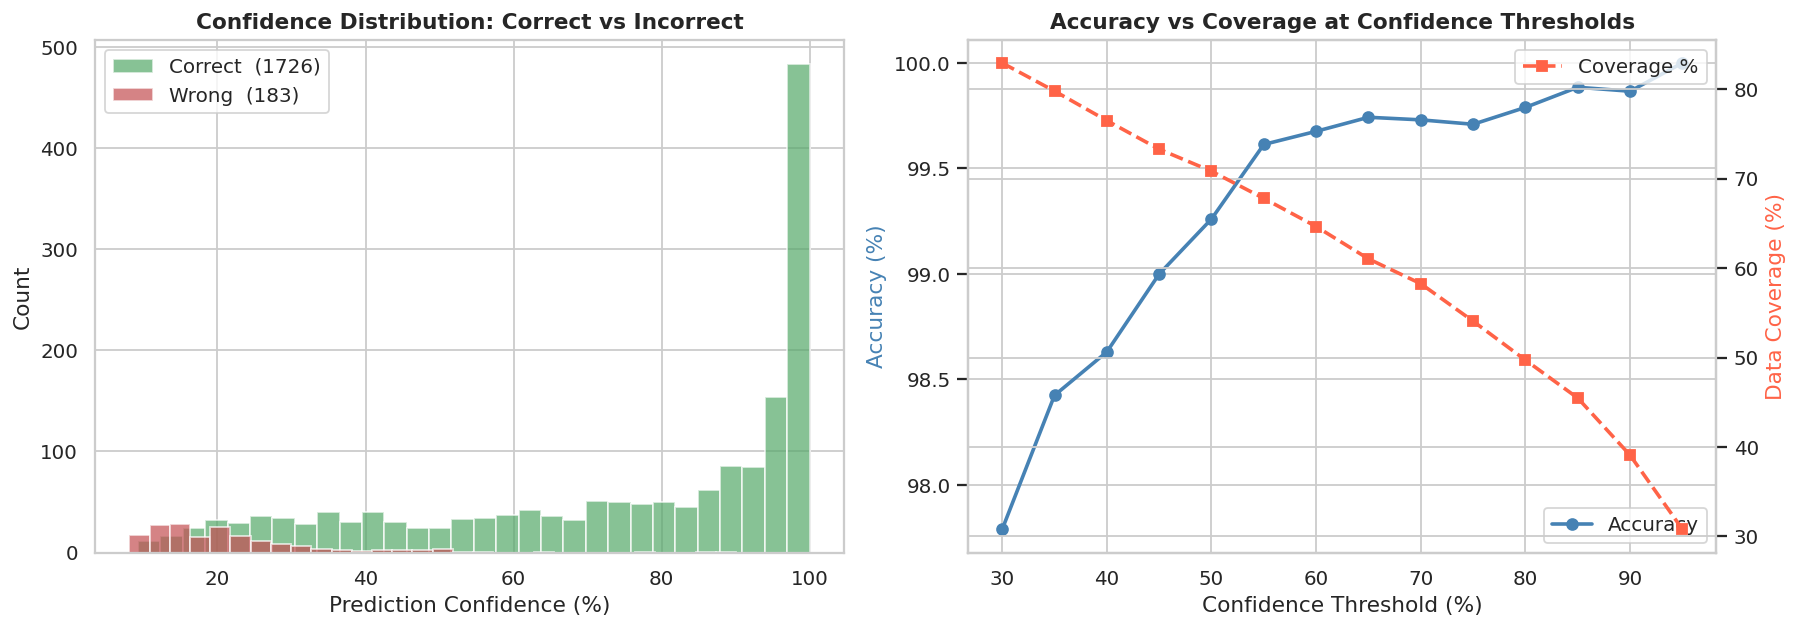


📊 Post-Prediction Metrics:
   Avg confidence (correct)  : 74.18%
   Avg confidence (incorrect): 22.92%
   Samples with conf ≥ 80%   : 949 / 1909


In [ ]:
test_proba   = BEST_CLF.predict_proba(X_test)
max_conf     = test_proba.max(axis=1) * 100
correct_mask = (BEST_CLF.predict(X_test) == y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(max_conf[correct_mask],  bins=30, alpha=0.7,
             color='#55A868', label=f'Correct  ({correct_mask.sum()})')
axes[0].hist(max_conf[~correct_mask], bins=30, alpha=0.7,
             color='#C44E52', label=f'Wrong  ({(~correct_mask).sum()})')
axes[0].set_xlabel('Prediction Confidence (%)')
axes[0].set_ylabel('Count')
axes[0].set_title('Confidence Distribution: Correct vs Incorrect', fontweight='bold')
axes[0].legend()

thresholds = np.arange(30, 100, 5)
acc_at_thresh, coverage = [], []
y_pred_all = BEST_CLF.predict(X_test)
for t in thresholds:
    mask = max_conf >= t
    if mask.sum() > 0:
        acc_at_thresh.append(accuracy_score(y_test[mask], y_pred_all[mask]) * 100)
        coverage.append(mask.sum() / len(y_test) * 100)
    else:
        acc_at_thresh.append(np.nan)
        coverage.append(0)

ax2 = axes[1]
ax2.plot(thresholds, acc_at_thresh, 'o-', color='steelblue', lw=2, label='Accuracy')
ax2b = ax2.twinx()
ax2b.plot(thresholds, coverage, 's--', color='tomato', lw=2, label='Coverage %')
ax2.set_xlabel('Confidence Threshold (%)')
ax2.set_ylabel('Accuracy (%)', color='steelblue')
ax2b.set_ylabel('Data Coverage (%)', color='tomato')
ax2.set_title('Accuracy vs Coverage at Confidence Thresholds', fontweight='bold')
ax2.legend(loc='lower right')
ax2b.legend(loc='upper right')

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/confidence_analysis.png', bbox_inches='tight')
plt.show()

print(f'\n📊 Post-Prediction Metrics:')
print(f'   Avg confidence (correct)  : {max_conf[correct_mask].mean():.2f}%')
print(f'   Avg confidence (incorrect): {max_conf[~correct_mask].mean():.2f}%')
print(f'   Samples with conf ≥ 80%   : {(max_conf >= 80).sum()} / {len(max_conf)}')

## 💾 STEP 23 — Save All Models & Final Summary

In [ ]:
import pickle

# Save everything to Drive
joblib.dump(le,       f'{MODEL_DIR}/label_encoder.pkl')
joblib.dump(BEST_CLF, f'{MODEL_DIR}/best_classifier.pkl')
sbert.save(f'{MODEL_DIR}/sbert_model')

with open(f'{MODEL_DIR}/job_skill_map.pkl', 'wb') as f:
    pickle.dump(JOB_SKILL_MAP, f)
with open(f'{MODEL_DIR}/skill_dict.pkl', 'wb') as f:
    pickle.dump(SKILL_DICT, f)

best = results_df.loc[results_df['Accuracy'].idxmax()]

print('\n' + '='*65)
print('  🎯  SkillLens AI — Final Training Summary')
print('='*65)
print(f'  Dataset            : {len(df):,} resumes · {NUM_CLASSES} job classes')
print(f'  Embedding Model    : {SBERT_MODEL} ({DIM}-dim)')
print(f'  FAISS Index        : {faiss_index.ntotal:,} vectors (IndexFlatIP)')
print()
print(f'  Best Model         : {best["Model"]}')
print(f'  Test Accuracy      : {best["Accuracy"]}%')
print(f'  Precision          : {best["Precision"]}%')
print(f'  Recall             : {best["Recall"]}%')
print(f'  F1-Score           : {best["F1-Score"]}%')
print(f'  Top-1 Accuracy     : {topk["Top-1"]}%')
print(f'  Top-3 Accuracy     : {topk["Top-3"]}%')
print(f'  Top-5 Accuracy     : {topk["Top-5"]}%')
print(f'  MRR                : {mrr:.4f}')
print(f'  CV Accuracy (5-fold): {cv_acc.mean()*100:.2f}% ± {cv_acc.std()*100:.2f}%')
print()
print(f'  All models saved to Drive:')
print(f'  {MODEL_DIR}/')
print('='*65)
print('\n✅ SkillLens AI pipeline complete!')
print('   → Run Streamlit app: streamlit run app.py')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  🎯  SkillLens AI — Final Training Summary
  Dataset            : 9,544 resumes · 28 job classes
  Embedding Model    : all-mpnet-base-v2 (768-dim)
  FAISS Index        : 9,544 vectors (IndexFlatIP)

  Best Model         : Logistic Regression
  Test Accuracy      : 90.41%
  Precision          : 90.5%
  Recall             : 90.41%
  F1-Score           : 90.38%
  Top-1 Accuracy     : 90.41%
  Top-3 Accuracy     : 96.39%
  Top-5 Accuracy     : 98.11%
  MRR                : 0.9369
  CV Accuracy (5-fold): 90.78% ± 0.57%

  All models saved to Drive:
  /content/drive/MyDrive/resume_project/skilllens_models/

✅ SkillLens AI pipeline complete!
   → Run Streamlit app: streamlit run app.py
